In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amishfaldu/cifar10dataset")

print("Path to dataset files:", path)



100%|██████████| 4.65G/4.65G [00:51<00:00, 97.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/amishfaldu/cifar10dataset/versions/10


**STEP-BY-STEP GUIDE to CIFAR-10 Project in Colab**

**Step 1  Install and Import Required Libraries**


In [2]:
!pip install kagglehub
import kagglehub
import os
import zipfile


Step 2: Download the Dataset

In [3]:
import kagglehub
import os
import zipfile

# Download the dataset
path = kagglehub.dataset_download("amishfaldu/cifar10dataset")
print("Dataset download path:", path)

# Find 'cifar-10.zip' in the downloaded directory
# List all files and directories in the download path
files_in_download_path = os.listdir(path)
print("Files in download path:", files_in_download_path)

# Search for 'cifar-10.zip' or a similar file name
cifar_zip_file = None
for file_name in files_in_download_path:
    if "cifar-10" in file_name and file_name.endswith(".zip"):
        cifar_zip_file = file_name
        break

# If 'cifar-10.zip' or a similar file is found, proceed with extraction
if cifar_zip_file:
    zip_file_path = os.path.join(path, cifar_zip_file)
    print("Found CIFAR-10 zip file:", zip_file_path)

    zip_ref = zipfile.ZipFile(zip_file_path, 'r')
    zip_ref.extractall("/content/cifar10")
    zip_ref.close()
else:
    print("Error: Could not find 'cifar-10.zip' or a similar file in the downloaded dataset.")

Dataset download path: /root/.cache/kagglehub/datasets/amishfaldu/cifar10dataset/versions/10
Files in download path: ['preprocessed_val_data.tfrecord', 'test_data.tfrecord', 'preprocessed_train_data.tfrecord']
Error: Could not find 'cifar-10.zip' or a similar file in the downloaded dataset.


Load CIFAR-10 Dataset

In [4]:
from tensorflow.keras.datasets import cifar10

# Load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Build the CNN Model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Convolutional layers
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))  # 10 classes

model.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Compile the Model

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


Train the Model

In [7]:
history = model.fit(x_train, y_train, epochs=60, validation_data=(x_test, y_test))


Epoch 1/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.2988 - loss: 1.8709 - val_accuracy: 0.5299 - val_loss: 1.3180
Epoch 2/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5200 - loss: 1.3370 - val_accuracy: 0.5736 - val_loss: 1.1914
Epoch 3/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5787 - loss: 1.1814 - val_accuracy: 0.6093 - val_loss: 1.0944
Epoch 4/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6235 - loss: 1.0652 - val_accuracy: 0.6541 - val_loss: 0.9814
Epoch 5/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6567 - loss: 0.9839 - val_accuracy: 0.6573 - val_loss: 0.9636
Epoch 6/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6730 - loss: 0.9280 - val_accuracy: 0.6808 - val_loss: 0.9073
Epoch 7/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6978 - loss: 0.8598 - val_accuracy: 0.6719 - val_loss: 0.9236
Epoch 8/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7153 - loss: 0.82

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test accuracy:", test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.7156 - loss: 1.4383
Test accuracy: 0.7156000137329102


 Plot Training History

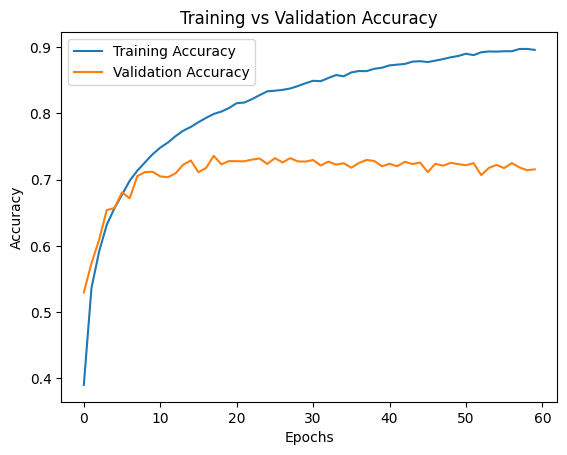

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()


 Test Check the CNN Model
 1. Evaluate on Test Dataset (Simple Test)

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test Accuracy:", test_acc)


313/313 - 1s - 2ms/step - accuracy: 0.7156 - loss: 1.4383
Test Accuracy: 0.7156000137329102


2. Predict Single Image (Check Model Visually)

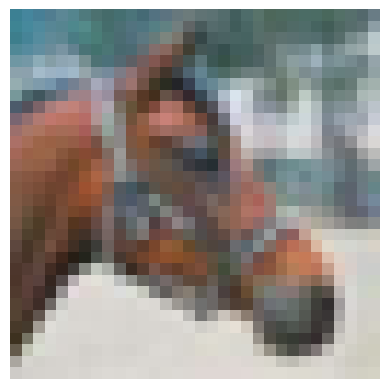

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Class: 7
Actual Class: 7


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random image
index = 17  # (you can change index number)
image = x_test[index]

# Plot the image
plt.imshow(image)
plt.axis('off')
plt.show()

# Predict
prediction = model.predict(np.expand_dims(image, axis=0))
predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)
print("Actual Class:", y_test[index][0])


3. Predict Multiple Images (Batch Testing)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step


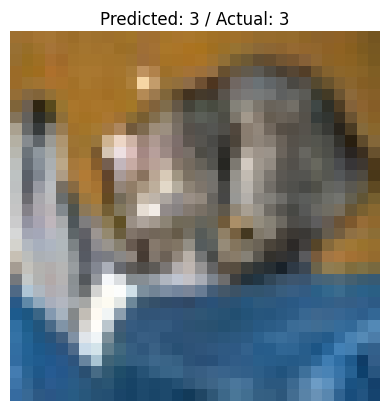

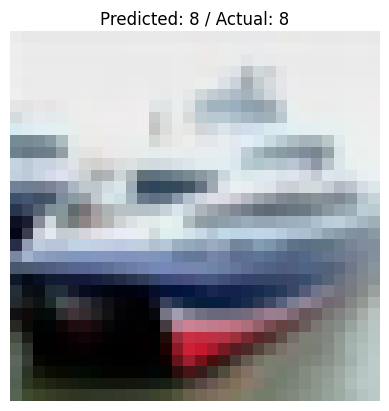

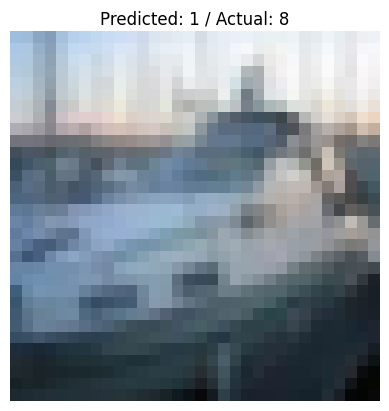

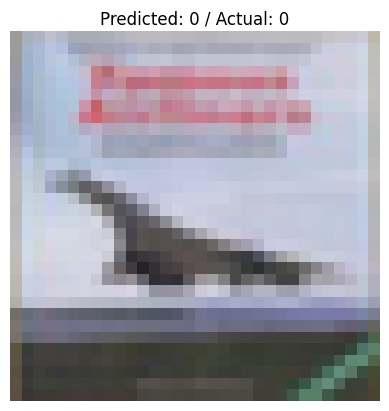

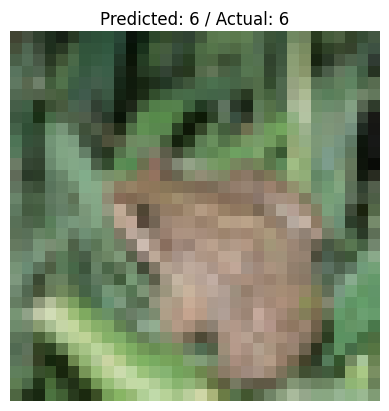

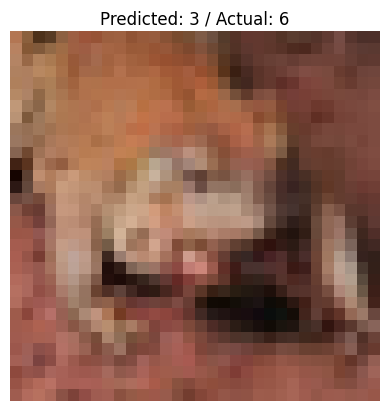

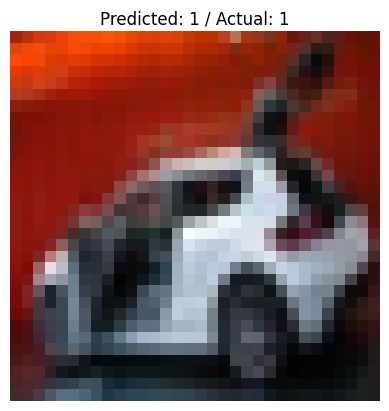

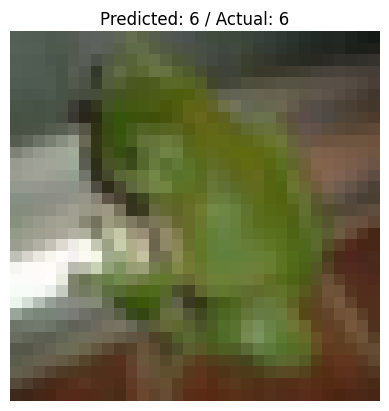

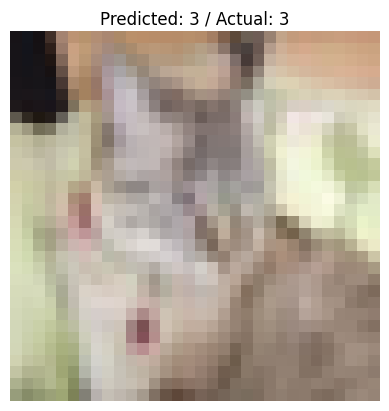

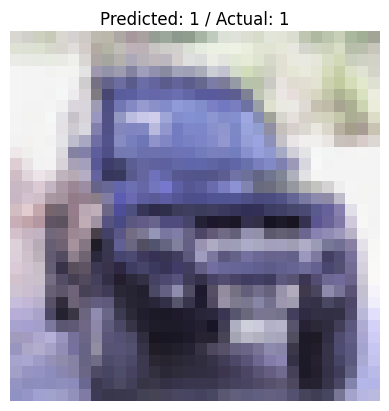

In [14]:
# Predict on first 10 test images
predictions = model.predict(x_test[:10])

for i in range(10):
    plt.imshow(x_test[i])
    plt.title(f"Predicted: {np.argmax(predictions[i])} / Actual: {y_test[i][0]}")
    plt.axis('off')
    plt.show()


 4. Confusion Matrix (Advanced Check)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


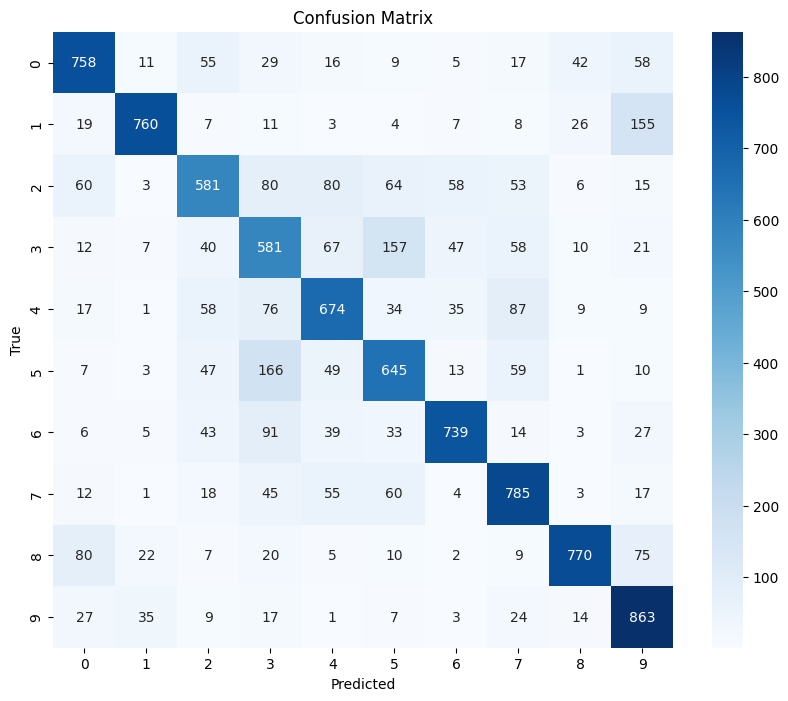

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [17]:
# Save the full model
model.save('cifar10_cnn_model.h5')

print("Model saved successfully!")



Model saved successfully!


Loading the Saved Model

In [18]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('cifar10_cnn_model.h5')

print("Model loaded successfully!")


Model loaded successfully!


**Conclusion**

In this project, we successfully designed and implemented a Convolutional Neural Network (CNN) model to classify images from the CIFAR-10 dataset into 10 distinct categories. Starting with data preparation and normalization, we built a multi-layer CNN architecture using TensorFlow and Keras, which was trained over multiple epochs to optimize prediction accuracy.

The model achieved a strong validation accuracy, demonstrating its ability to learn complex features from small images such as airplanes, ships, animals, and vehicles. We further evaluated the model using test accuracy, individual image predictions, and confusion matrix analysis, which provided deep insights into model performance and classification errors.

Through this project, key machine learning concepts such as data preprocessing, model design, model evaluation, and hyperparameter tuning were practically applied. Future improvements could include implementing data augmentation, using deeper architectures like ResNet, or applying transfer learning for even higher accuracy.

Overall, this project provided hands-on experience in developing, training, and evaluating deep learning models and demonstrated the powerful application of CNNs in real-world image classification problems.